In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rumethsandinu/neobreath")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/rumethsandinu/neobreath/versions/1


In [65]:
import torch
import random

In [66]:
# configs
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {DEVICE}")

# paths
DATA_PATH = "/root/.cache/kagglehub/datasets/rumethsandinu/neobreath/versions/1/PET/up_threshold_0.7"
CKPT_PATH = "/content/ckpt_ep20.pt"
SPLIT_FILE = "/content/split_seed42_aug_80_20_balanced.json"

RESULTS_FILE = "fid_is_up_7_20.json"

# hyperparams
IMAGE_SIZE = 128
SEQ_LENGTH = 8

# sequences per class for eval
SEQS_PER_CLASS = 25
TOTAL_SEQS = SEQS_PER_CLASS * 3
BATCH_SIZE = 8
GENERATION_STEPS = 50
CLASSES = ["A", "B", "G"]

# reproducibility
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Running on device: cuda


In [67]:
import numpy as np
from tqdm.auto import tqdm
from scipy import linalg
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import functional as TF
from torchvision.models import inception_v3, Inception_V3_Weights
import warnings
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [68]:
"""Utility functions and InceptionV3 wrapper for FID / IS computation.

This cell defines:
- InceptionV3Wrapper: extracts pool3 features and logits from InceptionV3
- get_stats: computes Gaussian stats (mu, sigma) and logits probabilities
- calc_fid: Fréchet Inception Distance between two Gaussians
- calc_is: Inception Score from predicted class probabilities
- plot_sample_sequences / print_label_distribution: visual diagnostics
"""

# Inception v3
class InceptionV3Wrapper(nn.Module):
    """Wrapper for InceptionV3: returns pool3 features (FID) and logits (IS)."""
    def __init__(self):
        super().__init__()

        # load pretrained InceptionV3 weights
        self.model = inception_v3(weights=Inception_V3_Weights.DEFAULT)
        self.model.eval()

        # store features from the last pooling layer (pool3)
        self.pool3 = None
        self.model.avgpool.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):

        # flatten pooled features to shape (B, 2048)
        if out.dim() == 4:
            out = out.flatten(2).mean(-1)
        self.pool3 = out.flatten(1)

    @torch.no_grad()
    def forward(self, x: torch.Tensor):
        """Forward pass.

        Args:
            x: Tensor of shape (B, 1, H, W) with values in [0, 1].

        Returns:
            pool3 features and logits tensor.
        """
        # resize to 299x299 required by InceptionV3
        x = TF.resize(x, [299, 299], interpolation=TF.InterpolationMode.BILINEAR)

        # convert 1-channel image to 3-channel by repetition
        x = x.repeat(1, 3, 1, 1)

        # normalise with ImageNet statistics
        x = TF.normalize(x, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        out = self.model(x)

        # handle different torchvision return types (Tensor or InceptionOutputs)
        logits = out.logits if hasattr(out, "logits") else out
        return self.pool3, logits


def get_stats(loader: DataLoader, evaluator: nn.Module, device: torch.device):
    """Compute Gaussian statistics and probabilities from a DataLoader.

    For each batch of sequences, frames are flattened and passed through
    InceptionV3. Then aggregate:
    - features (for FID)
    - softmax probabilities (for IS)
    """
    evaluator.to(device)
    feats, probs = [], []

    # disable progress bar for trivial (<=1 batch) loaders to avoid 0% lines
    try:
        disable_bar = len(loader) <= 1
    except TypeError:
        disable_bar = False

    for seqs, _ in tqdm(loader, leave=False, disable=disable_bar):

        # seqs: (B, T, 1, H, W). Flatten over time T
        B, T, C, H, W = seqs.shape
        x = seqs.view(-1, C, H, W).to(device)

        with torch.no_grad():
            f, l = evaluator(x)
            p = F.softmax(l, dim=1)

        # accumulate features / probabilities on CPU to save VRAM
        feats.append(f.cpu().numpy())
        probs.append(p.cpu())
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    feats = np.concatenate(feats, axis=0) if len(feats) else np.zeros((0, 2048), dtype=np.float32)
    probs = torch.cat(probs, dim=0) if len(probs) else torch.empty(0, 1000)

    # fit Gaussian N(mu, sigma) to features
    if feats.shape[0] == 0:
        raise RuntimeError("No frames found in loader to compute statistics.")
    mu = np.mean(feats, axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma, probs


def calc_fid(mu1: np.ndarray, s1: np.ndarray, mu2: np.ndarray, s2: np.ndarray, eps: float = 1e-6) -> float:
    """Compute Fréchet Inception Distance between two Gaussians.

    FID = ||mu1 - mu2||^2 + Tr(S1 + S2 - 2 * (S1 S2)^{1/2})

    Uses a small diagonal offset to stabilise the covariance product and
    avoids deprecated SciPy arguments.
    """
    diff = mu1 - mu2

    # add small offset to diagonals for numerical stability (handles near-singular covariances)
    offset = np.eye(s1.shape[0], dtype=s1.dtype) * eps
    s1_stable = s1 + offset
    s2_stable = s2 + offset

    cov_prod = s1_stable @ s2_stable

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=linalg.LinAlgWarning)
        covmean = linalg.sqrtm(cov_prod)

    # discard tiny imaginary component if present
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # if still not finite (rare), increase offset and recompute
    if not np.isfinite(covmean).all():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=linalg.LinAlgWarning)
            boost = np.eye(s1.shape[0], dtype=s1.dtype) * (eps * 10.0)
            covmean = linalg.sqrtm((s1 + boost) @ (s2 + boost))
        if np.iscomplexobj(covmean):
            covmean = covmean.real

    fid = diff.dot(diff) + np.trace(s1_stable) + np.trace(s2_stable) - 2.0 * np.trace(covmean)
    return float(fid)


def calc_is(probs: torch.Tensor, splits: int = 1):
    """Compute Inception Score from softmax probabilities.

    Args:
        probs: Tensor of shape (N, num_classes). Each row sums to 1.
        splits: Number of splits used to compute IS mean/std.

    Returns:
        (IS_mean)
    """
    N = probs.shape[0]

    # ensure splits is at most N and at least 1
    splits = min(splits, N) if N > 0 else 1
    split_sz = max(N // splits, 1)

    scores = []
    for k in range(splits):
        part = probs[k * split_sz : (k + 1) * split_sz]
        if part.numel() == 0:
            continue

        # KL divergence between conditional label distribution and marginal
        kl = part * (torch.log(part + 1e-10) - torch.log(part.mean(0) + 1e-10))
        scores.append(torch.exp(kl.sum(1).mean()))

    scores = torch.stack(scores)
    return scores.mean().item()


def plot_sample_sequences(loader: DataLoader, title: str, n_seqs: int = 3, n_cols: int = 8):
    """Plot a few sequences (first channel) from a loader for inspection.

    Shows up to `n_seqs` sequences with up to `n_cols` frames each.
    """
    plt.figure(figsize=(3 * n_cols, 3 * n_seqs))
    shown = 0

    for seqs, labels in loader:
        B, T, C, H, W = seqs.shape
        for b in range(min(B, n_seqs - shown)):
            for t in range(min(T, n_cols)):
                plt.subplot(n_seqs, n_cols, b * n_cols + t + 1)
                img = seqs[b, t, 0].numpy()
                plt.imshow(img, cmap="hot")
                plt.axis("off")
        shown += B
        if shown >= n_seqs:
            break

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def print_label_distribution(loader: DataLoader, name: str):
    """Print how many sequences per class are present in a DataLoader."""
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.numpy().tolist())

    all_labels = np.array(all_labels)
    print(f"Label distribution for {name}:")
    for idx, cls in enumerate(CLASSES):
        count = int((all_labels == idx).sum())
        print(f"  Class {cls} ({idx}): {count} sequences")

In [69]:
# diffusers
try:
    from diffusers import UNet2DModel, DDPMScheduler
except ImportError:
    %pip install -q diffusers
    from diffusers import UNet2DModel, DDPMScheduler

In [70]:
# load ddpm model
ckpt = torch.load(CKPT_PATH, map_location="cpu")

#extract configuration and EMA shadow weights if available
config = ckpt.get("config", {})
ema_shadow = ckpt.get("ema")

# model configs
channels = config.get("channels", (64, 128, 256))
timesteps = int(config.get("timesteps", 1000))
prediction_type = config.get("prediction_type", "v_prediction")

# initialise UNet
model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
    class_embed_type="timestep",  # class-conditioning via timestep embedding
    num_class_embeds=len(CLASSES),
).to(DEVICE)

state_dict = ckpt.get("model", ckpt)
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys in state_dict:", len(missing))
print("Unexpected keys in state_dict:", len(unexpected))

if ema_shadow:
    ema_shadow = {k: v.to(DEVICE) for k, v in ema_shadow.items()}
    for name, param in model.named_parameters():
        if name in ema_shadow:
            param.data.copy_(ema_shadow[name])

model.eval()

# DDPM scheduler used to perform the reverse diffusion sampling process
scheduler = DDPMScheduler(
    num_train_timesteps=timesteps,
    beta_schedule="squaredcos_cap_v2",
    prediction_type=prediction_type,
)

Missing keys in state_dict: 0
Unexpected keys in state_dict: 0


In [71]:
# generate samples (memory-aware)
@torch.no_grad()
def generate_sequences(model, scheduler, class_idx: int, n_seqs: int, steps: int = GENERATION_STEPS):
    """Generate `n_seqs` synthetic sequences for a given class.

    Args:
        model: Trained UNet2DModel.
        scheduler: DDPMScheduler initialised with training settings.
        class_idx: Integer index of class in `CLASSES`.
        n_seqs: Number of sequences to generate for this class.
        steps: Number of diffusion sampling steps (<= training timesteps).

    Returns:
        Tensor of shape (n_seqs, SEQ_LENGTH, 1, IMAGE_SIZE, IMAGE_SIZE)
        containing generated frames in [-1, 1].
    """

    model.eval()
    total_frames = n_seqs * SEQ_LENGTH

    # random noise on GPU
    x = torch.randn(total_frames, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)

    # class labels for conditional generation (one label per frame)
    labels = torch.full((total_frames,), class_idx, device=DEVICE, dtype=torch.long)

    # configure scheduler timesteps for inference
    scheduler.set_timesteps(steps)
    timesteps = scheduler.timesteps

    # process the diffusion reverse steps in mini-batches to fit into VRAM
    batch_size = 32
    for t in tqdm(timesteps, desc=f"Sampling class {CLASSES[class_idx]}", leave=False):
        for i in range(0, total_frames, batch_size):
            end = min(i + batch_size, total_frames)
            batch_x = x[i:end]
            batch_lbl = labels[i:end]

            # build tensor of current timesteps for this batch
            batch_t = torch.full((end - i,), t, device=DEVICE, dtype=torch.long)
            out = model(batch_x, batch_t, class_labels=batch_lbl).sample
            x[i:end] = scheduler.step(out, t, batch_x).prev_sample

        # free CUDA memory between steps when using GPU
        torch.cuda.empty_cache()

    # reshape back into sequences: (n_seqs, T, C, H, W)
    return x.view(n_seqs, SEQ_LENGTH, 1, IMAGE_SIZE, IMAGE_SIZE).cpu()

In [72]:
from torch.utils.data import Dataset

In [73]:
# generate synthetic dataset
synthetic_data = []
seqs_per_class = SEQS_PER_CLASS

# generate sequences per class
for i, cls in enumerate(CLASSES):
    seqs = generate_sequences(model, scheduler, i, seqs_per_class, steps=GENERATION_STEPS)
    for s in seqs:
        synthetic_data.append((s, i))
    torch.cuda.empty_cache()

print(f"Total synthetic sequences: {len(synthetic_data)}")

class SyntheticDataset(Dataset):
    """Wrap list of synthetic sequences into a Dataset.

    Each item is returned as (sequence, label), where:
      - sequence: Tensor (T, 1, H, W) in [0, 1]
      - label: LongTensor scalar in {0, 1, 2}
    """

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, lbl = self.data[idx]

        # denormalize [-1, 1] -> [0, 1]
        seq = (seq.clamp(-1, 1) + 1) / 2.0
        return seq, torch.tensor(lbl, dtype=torch.long)


# stack sequences and labels into batch tensors
synth_loader = DataLoader(
    SyntheticDataset(synthetic_data),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda b: (torch.stack([x[0] for x in b]), torch.stack([x[1] for x in b])),
)

Sampling class A:   0%|          | 0/50 [00:00<?, ?it/s]

Sampling class B:   0%|          | 0/50 [00:00<?, ?it/s]

Sampling class G:   0%|          | 0/50 [00:00<?, ?it/s]

Total synthetic sequences: 75


In [74]:
from pathlib import Path
from torchvision.transforms import InterpolationMode

In [75]:
# dataset matching training for consistent split indices

class PETDataset(Dataset):
    """
    Identical sequence construction to training notebook (ddpm-up-8):
    - Loads .npy volumes under class subfolders
    - Splits into fixed-length sequences (SEQ_LENGTH)
    - Optionally appends 1 augmented copy per sequence (slice-wise)
    - __getitem__ returns tensors in [-1, 1] with shape (T, 1, H, W)
    """
    def __init__(self, data_dir, classes, seq_len=8, image_size=128, augment=True, augment_times=1):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.seq_len = int(seq_len)
        self.image_size = int(image_size)
        self.augment = bool(augment)
        self.augment_times = max(1, int(augment_times))

        self.sequences = []  # list of (np.ndarray[T,H,W] in [0,1], class_idx, is_aug)

        # load all sequences in deterministic order
        for cls in classes:
            cls_dir = self.data_dir / cls
            if not cls_dir.exists():
                print(f"Warning: data directory for class '{cls}' does not exist: {cls_dir}")
                continue
            for npy_file in sorted(cls_dir.glob("*.npy")):
                vol = np.load(npy_file)
                n_full = vol.shape[0] // self.seq_len
                if n_full == 0:
                    continue
                for i in range(n_full):
                    start = i * self.seq_len
                    chunk = vol[start:start + self.seq_len]
                    if chunk.shape[0] != self.seq_len:
                        continue
                    self.sequences.append((chunk.astype(np.float32), self.class_to_idx[cls], False))
                    if self.augment:
                        for _ in range(self.augment_times):
                            aug_chunk = np.stack([self._augment_slice(s) for s in chunk])
                            self.sequences.append((aug_chunk.astype(np.float32), self.class_to_idx[cls], True))

    def _augment_slice(self, slice_np):
        t = torch.from_numpy(slice_np).unsqueeze(0)
        if random.random() > 0.5:
            t = TF.hflip(t)
        if random.random() > 0.5:
            t = TF.vflip(t)
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            t = TF.rotate(t, angle, interpolation=InterpolationMode.BILINEAR)
        if random.random() > 0.5:
            factor = random.uniform(0.9, 1.1)
            t = TF.adjust_brightness(t, factor)
        out = t.squeeze(0).numpy()
        return np.clip(out, 0.0, 1.0)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq, cls_idx, _ = self.sequences[idx]
        # map to [-1,1] to match training preprocessing
        seq = seq.astype(np.float32) * 2.0 - 1.0
        tensor_seq = torch.from_numpy(seq).unsqueeze(1)  # (T,1,H,W)
        _, _, H, W = tensor_seq.shape
        if (H, W) != (self.image_size, self.image_size):
            tensor_seq = torch.nn.functional.interpolate(
                tensor_seq, size=(self.image_size, self.image_size), mode='bilinear', align_corners=False
            )
        return tensor_seq, torch.tensor(cls_idx, dtype=torch.long)

In [76]:
import json
from torch.utils.data import Subset

In [77]:
# limit real test sequences per class
N_PER_CLASS = 25

# helper: load test indices from split file

def load_test_indices(split_path: str):
    p = Path(split_path)
    if not p.exists():
        raise FileNotFoundError(f"Split file not found: {p}")
    with open(p, "r") as f:
        data = json.load(f)
    if not isinstance(data, dict) or "test_indices" not in data:
        raise ValueError("Split file missing 'test_indices' field.")
    idxs = data["test_indices"]
    if not isinstance(idxs, list):
        raise ValueError("'test_indices' must be a list of integers.")
    return [int(x) for x in idxs]

# build dataset identical to training to ensure indices align
base_dataset = PETDataset(
    data_dir=DATA_PATH,
    classes=CLASSES,
    seq_len=SEQ_LENGTH,
    image_size=IMAGE_SIZE,
    augment=True,
    augment_times=1,
)

# get test subset indices
try:
    test_indices = load_test_indices(SPLIT_FILE)
except Exception as e:
    raise RuntimeError(f"Failed to read split file '{SPLIT_FILE}': {e}")

# validate indices
max_idx = len(base_dataset) - 1
valid_test_indices = sorted({i for i in test_indices if 0 <= i <= max_idx})
if len(valid_test_indices) != len(test_indices):
    dropped = len(test_indices) - len(valid_test_indices)
    print(f"Warning: Dropped {dropped} out-of-range indices (dataset size={len(base_dataset)}).")

# per-class limiting: pick up to N_PER_CLASS test indices for each class deterministically
per_class_indices = {cls_i: [] for cls_i in range(len(CLASSES))}
for idx in valid_test_indices:
    _, lbl, _ = base_dataset.sequences[idx]
    cls_i = int(lbl)
    if len(per_class_indices[cls_i]) < N_PER_CLASS:
        per_class_indices[cls_i].append(idx)

# flatten selected indices in a stable order
selected_indices = []
for cls_i in range(len(CLASSES)):
    selected_indices.extend(sorted(per_class_indices[cls_i]))

# report any shortages
for cls_i, cls_name in enumerate(CLASSES):
    if len(per_class_indices[cls_i]) < N_PER_CLASS:
        print(f"Note: class {cls_name} only has {len(per_class_indices[cls_i])} test sequences (requested {N_PER_CLASS}).")

# subset for real test sequences
test_dataset = Subset(base_dataset, selected_indices)

# collate: convert [-1,1] -> [0,1] for evaluation

def collate_eval(batch):
    seqs, lbls = zip(*batch)
    seqs = [((s.clamp(-1, 1) + 1.0) / 2.0) for s in seqs]
    return torch.stack(seqs), torch.stack(lbls)

real_loader = None
if len(test_dataset) > 0:
    real_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=collate_eval,
    )

    # quick summary
    counts = {cls: 0 for cls in CLASSES}
    for idx in selected_indices:
        _, lbl, _ = base_dataset.sequences[idx]
        counts[CLASSES[int(lbl)]] += 1
    print(f"Real test sequences: {len(test_dataset)}")
    print("Per-class counts:", counts)
else:
    print("Error: No real test data found using provided split.")

Real test sequences: 75
Per-class counts: {'A': 25, 'B': 25, 'G': 25}


In [78]:
import threading

Real batches: 10 | seqs: 75
Synth batches: 10 | seqs: 75


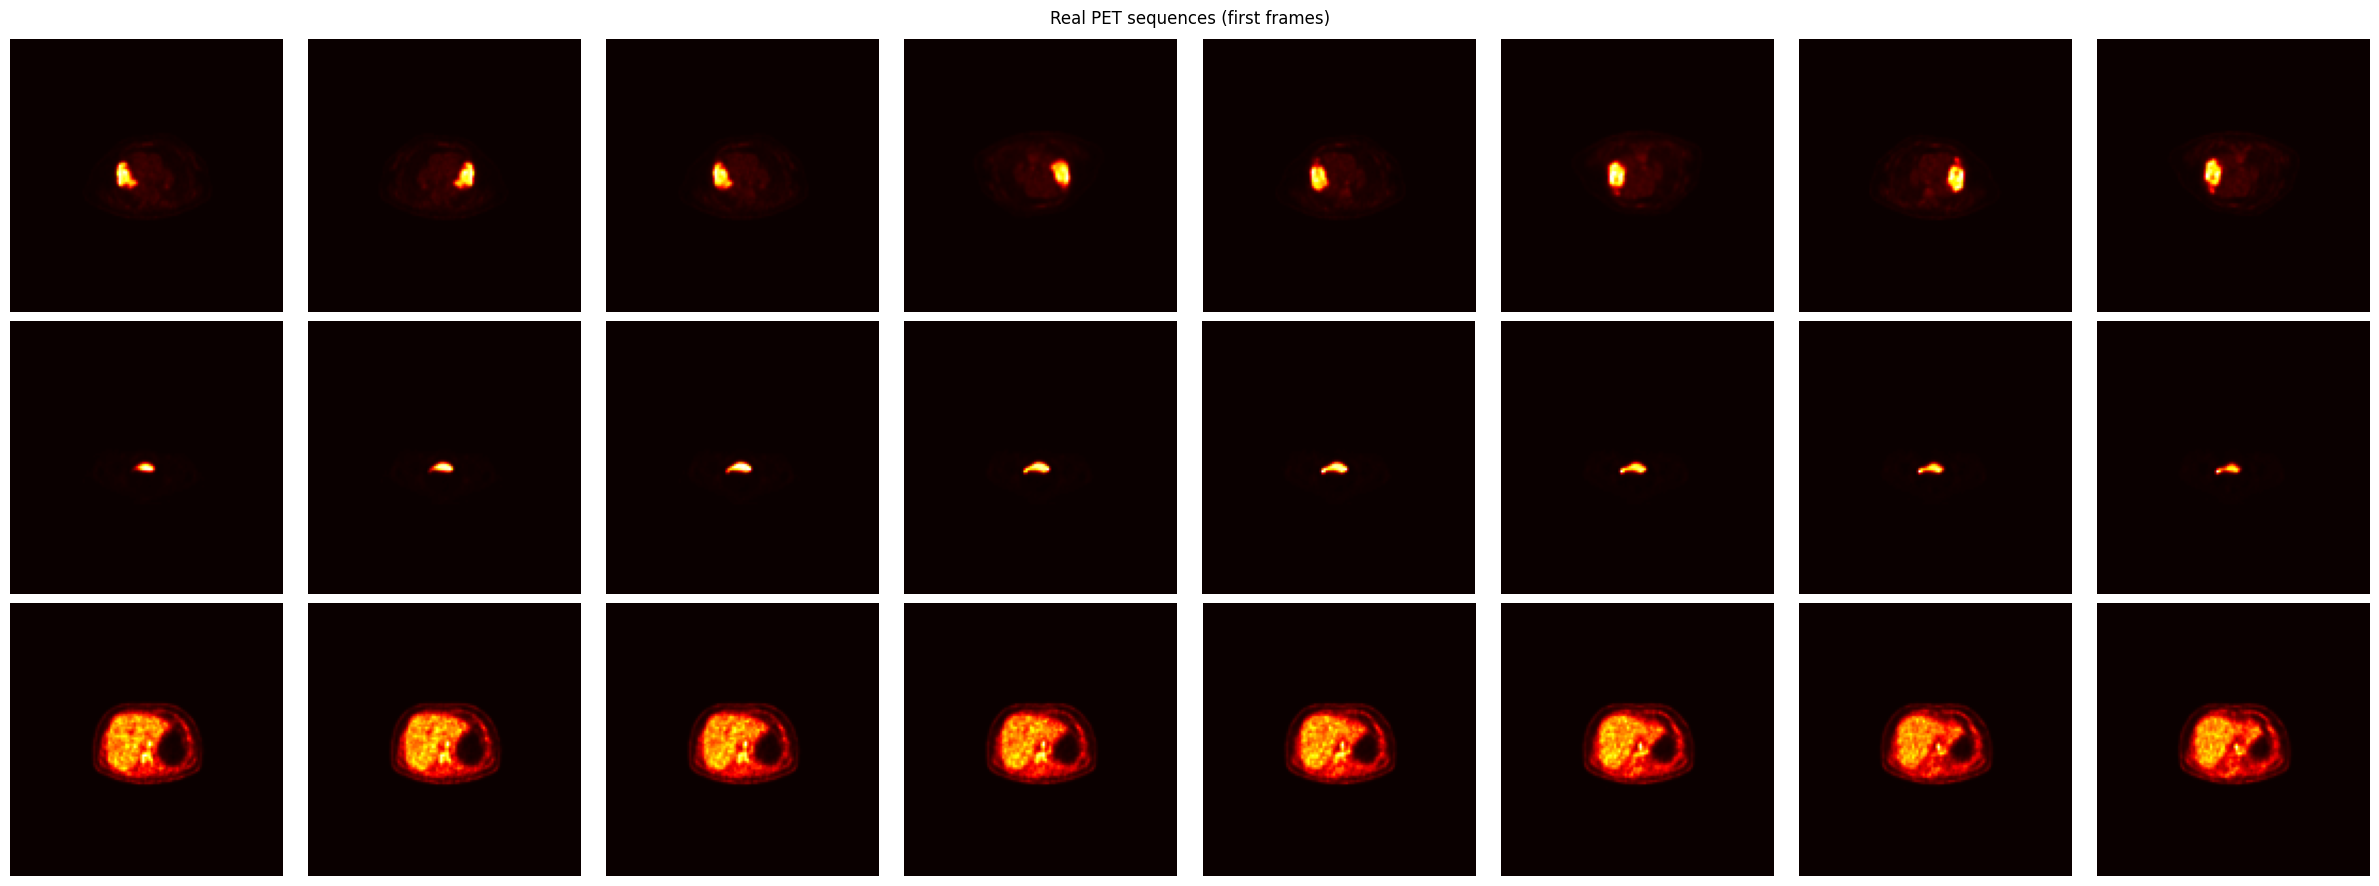

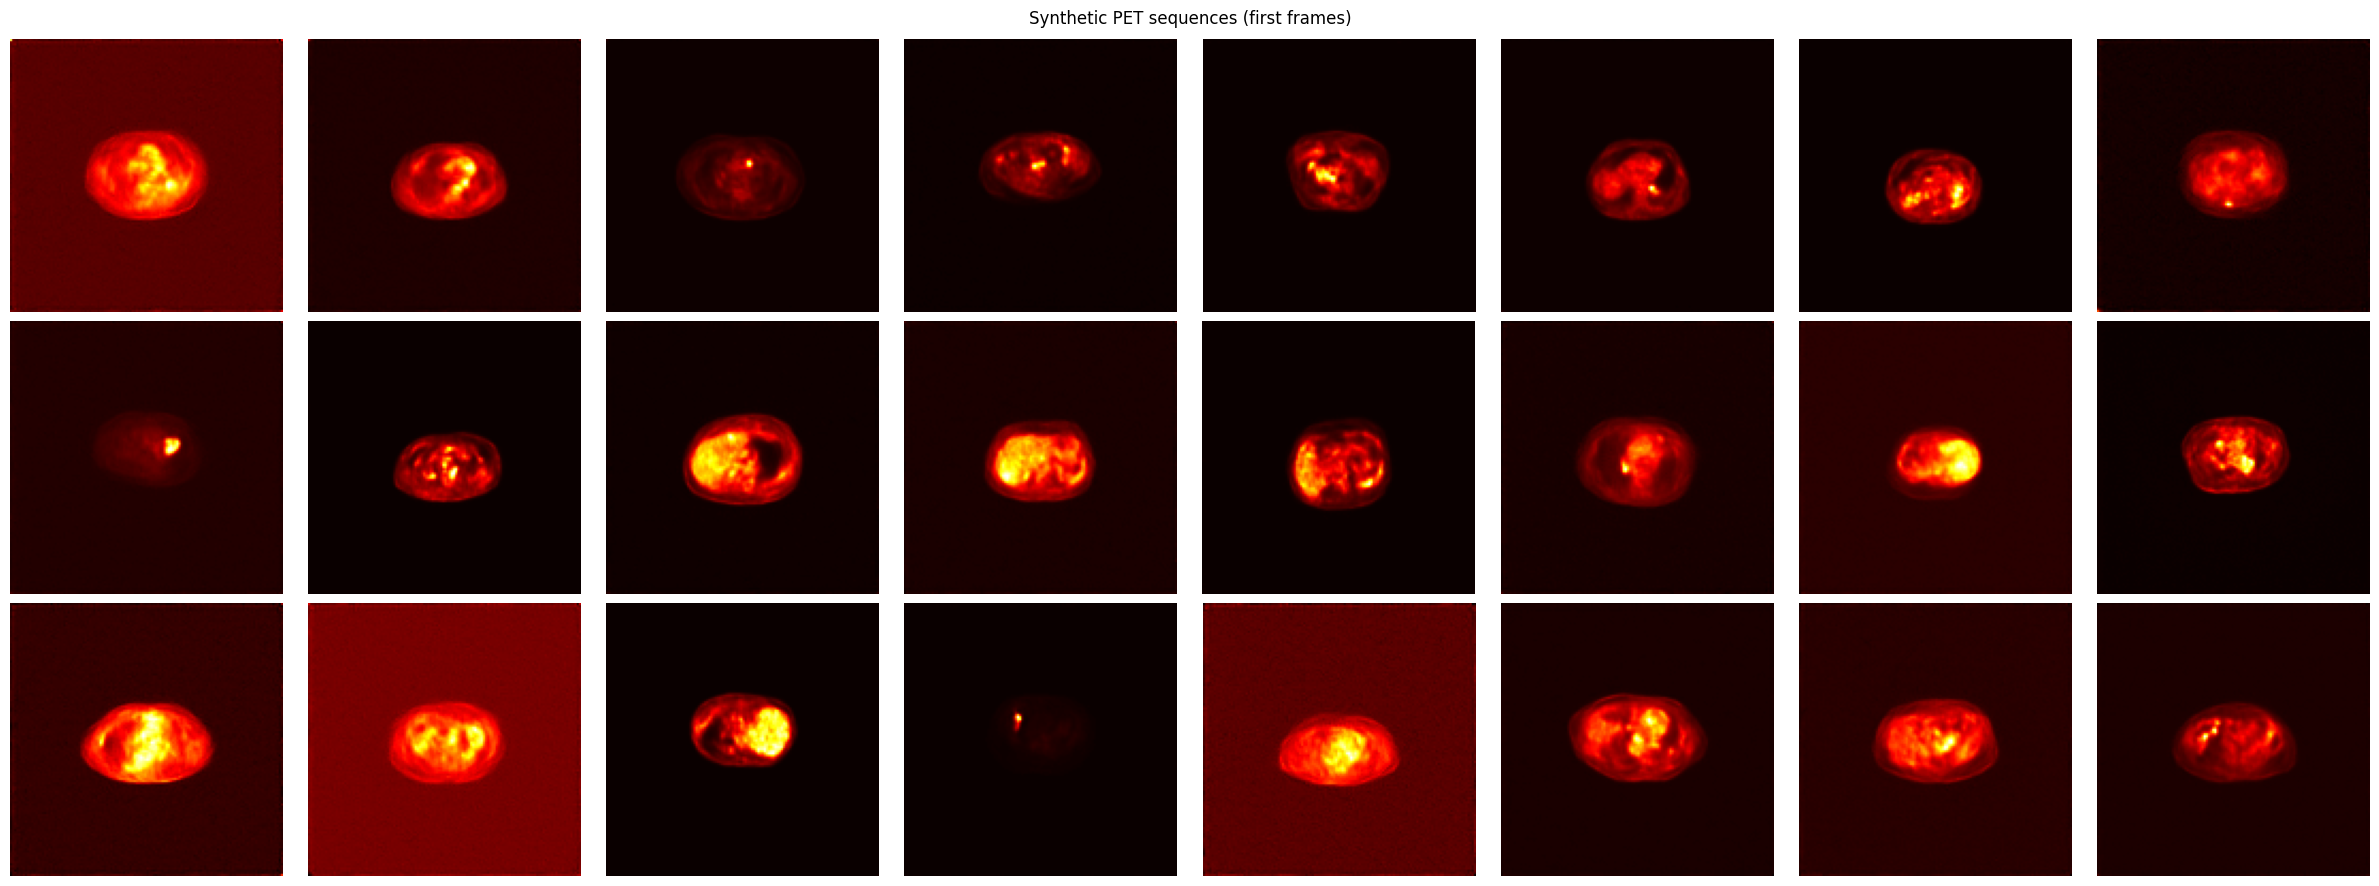

Label distribution for Real:
  Class A (0): 25 sequences
  Class B (1): 25 sequences
  Class G (2): 25 sequences
Label distribution for Synthetic:
  Class A (0): 25 sequences
  Class B (1): 25 sequences
  Class G (2): 25 sequences


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Evaluation results (InceptionV3 on frames)
FID: 25.5679
IS:  1.8123
Saved results to fid_is_up_7_20.json


In [79]:
# run evaluation with a robust single-run lock
_EVAL_LOCK = globals().get('_EVAL_LOCK', threading.Lock())

if not _EVAL_LOCK.acquire(blocking=False):
    print("Evaluation already running; skipped duplicate trigger.")
else:
    try:
        if real_loader is None:
            print("Skipped evaluation (no real data).")
        else:
            # quick sanity info before heavy compute
            try:
                print(f"Real batches: {len(real_loader)} | seqs: {len(real_loader.dataset)}")
                print(f"Synth batches: {len(synth_loader)} | seqs: {len(synth_loader.dataset)}")
            except Exception:
                pass

            # plot and distributions before evaluation
            plot_sample_sequences(real_loader, "Real PET sequences (first frames)")
            plot_sample_sequences(synth_loader, "Synthetic PET sequences (first frames)")
            print_label_distribution(real_loader, "Real")
            print_label_distribution(synth_loader, "Synthetic")

            # compute FID + Inception Score
            try:
                evaluator = InceptionV3Wrapper().to(DEVICE)
                mu_r, s_r, _ = get_stats(real_loader, evaluator, DEVICE)
                mu_s, s_s, probs_s = get_stats(synth_loader, evaluator, DEVICE)

                # Fréchet Inception Distance
                fid = calc_fid(mu_r, s_r, mu_s, s_s)

                # Inception Score
                is_mean = calc_is(probs_s)

                results = {
                    "FID": float(fid),
                    "IS_mean": float(is_mean),
                    "num_real_sequences": len(real_loader.dataset),
                    "num_synth_sequences": len(synth_loader.dataset),
                }

                print("Evaluation results (InceptionV3 on frames)")
                print(f"FID: {fid:.4f}")
                print(f"IS:  {is_mean:.4f}")

                # save to JSON file
                with open(RESULTS_FILE, "w") as f:
                    json.dump(results, f, indent=4)
                print(f"Saved results to {RESULTS_FILE}")
            except Exception as e:
                print(f"Evaluation failed: {e}")
    finally:
        _EVAL_LOCK.release()